## **Imports**

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# **Question 01**

In [3]:
# Load the data skipping the header
D = np.genfromtxt("lines.csv", delimiter=",", skip_header=1)

# Extract individual columns for part (a)
x1 = D[:, 0]
y1 = D[:, 3]

# Prepare all points for part (b)
X_cols = D[:, :3]
Y_cols = D[:, 3:]
X_all = X_cols.flatten()
Y_all = Y_cols.flatten()
points_all = np.column_stack((X_all, Y_all))

#### **Q1 Part (a)**

In [7]:
def total_least_squares(x, y):
    # 1. Center the data (Line must pass through the centroid)
    x_mean, y_mean = np.mean(x), np.mean(y)
    x_centered = x - x_mean
    y_centered = y - y_mean
    
    # 2. Form the matrix A
    A = np.column_stack((x_centered, y_centered))
    
    # 3. Compute SVD 
    # The last row of Vt is the eigenvector for the smallest eigenvalue
    _, _, Vt = np.linalg.svd(A)
    a, b = Vt[-1] # This is the normal vector
    
    # 4. Calculate d for the equation ax + by + d = 0
    d = - (a * x_mean + b * y_mean)
    
    return a, b, d, x_mean, y_mean


In [8]:
a, b, d, x_m, y_m = total_least_squares(x1, y1)
print(f"Line parameters: a={a:.4f}, b={b:.4f}, d={d:.4f}")

Line parameters: a=0.7736, b=-0.6337, d=-3.7942


### **TLS Result**
The parameters $(a=0.7736, b=-0.6337, d=-3.7942)$ 

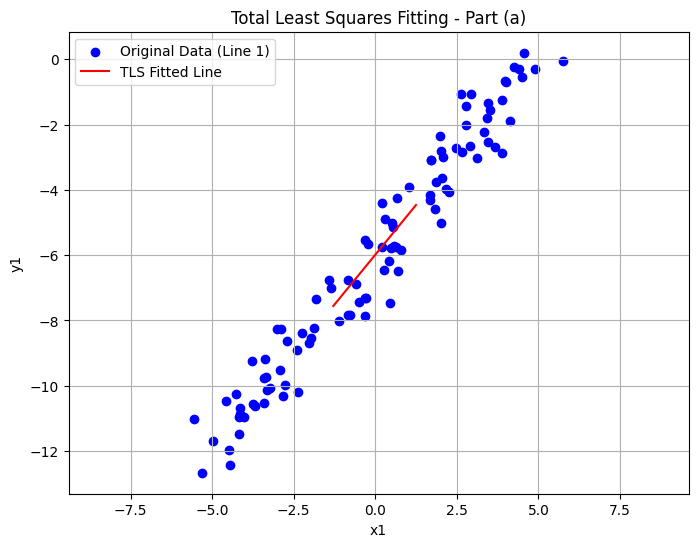

In [9]:
# --- PLOTTING SECTION ---

plt.figure(figsize=(8, 6))
plt.scatter(x1, y1, color='blue', label='Original Data (Line 1)')

# To plot the line, we find the direction vector, which is perpendicular to the normal (a, b)
# For a normal (a, b), the direction is (-b, a)
dir_x, dir_y = -b, a

# Generate points along the line using the centroid and direction
t = np.linspace(-2, 2, 100) 
line_x = x_m + t * dir_x
line_y = y_m + t * dir_y

plt.plot(line_x, line_y, color='red', label='TLS Fitted Line')

# Formatting for your report
plt.xlabel('x1')
plt.ylabel('y1')
plt.title('Total Least Squares Fitting - Part (a)')
plt.legend()
plt.grid(True)
plt.axis('equal') # Essential to visualize perpendicular distance
plt.show()

### **Q1 Part (b) Sequential RANSAC**

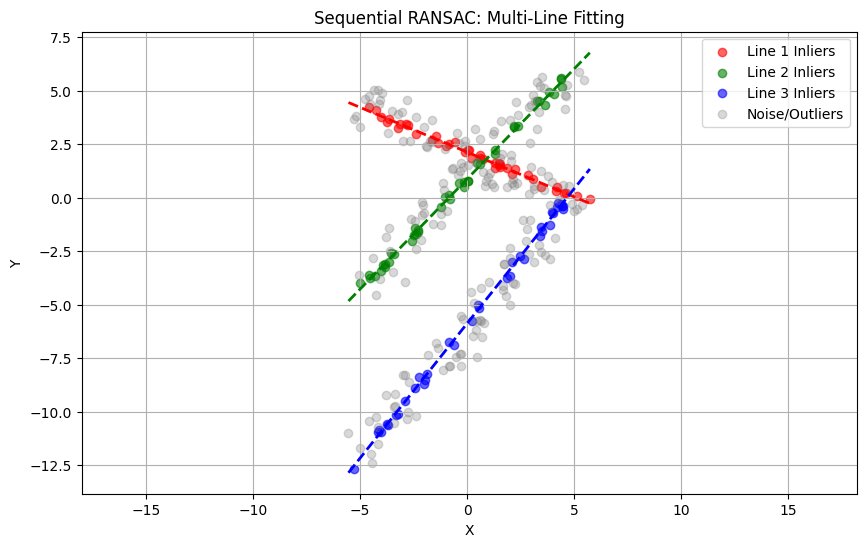

Line 1 Parameters: a=-0.3857, b=-0.9226, d=1.9723
Line 2 Parameters: a=0.7171, b=-0.6970, d=0.6099
Line 3 Parameters: a=0.7829, b=-0.6221, d=-3.6566


In [ ]:


points_all = np.column_stack((X_all, Y_all))

def get_line_from_points(p1, p2):
    a = p1[1] - p2[1]
    b = p2[0] - p1[0]
    d = - (a * p1[0] + b * p1[1])
    norm = np.sqrt(a**2 + b**2)
    if norm == 0: return 0, 0, 0
    return a/norm, b/norm, d/norm

def ransac_line(points, threshold=0.2, iterations=1000):
    best_inliers = []
    best_model = None
    
    for _ in range(iterations):
        idx = np.random.choice(len(points), 2, replace=False)
        p1, p2 = points[idx]
        
        a, b, d = get_line_from_points(p1, p2)
        distances = np.abs(a * points[:, 0] + b * points[:, 1] + d)
        inliers = np.where(distances < threshold)[0]
        
        if len(inliers) > len(best_inliers):
            best_inliers = inliers
            best_model = (a, b, d)
            
    return best_model, best_inliers

# --- 2. Sequential Execution & Plotting ---
plt.figure(figsize=(10, 6))
remaining_points = points_all.copy()
colors = ['red', 'green', 'blue']
line_params = []

for i in range(3):
    model, inlier_indices = ransac_line(remaining_points, threshold=0.2)
    line_params.append(model)
    a, b, d = model
    
    inliers = remaining_points[inlier_indices]
    plt.scatter(inliers[:, 0], inliers[:, 1], color=colors[i], 
                label=f'Line {i+1} Inliers', alpha=0.6)
    
    x_range = np.array([points_all[:,0].min(), points_all[:,0].max()])
    y_range = (-a * x_range - d) / b
    plt.plot(x_range, y_range, color=colors[i], linestyle='--', linewidth=2)
    remaining_points = np.delete(remaining_points, inlier_indices, axis=0)

# Plot any leftover points (outliers/noise) in gray
if len(remaining_points) > 0:
    plt.scatter(remaining_points[:, 0], remaining_points[:, 1], 
                color='gray', alpha=0.3, label='Noise/Outliers')

plt.title("Sequential RANSAC: Multi-Line Fitting")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.axis('equal')
plt.grid(True)
plt.show()


for i, p in enumerate(line_params):
    print(f"Line {i+1} Parameters: a={p[0]:.4f}, b={p[1]:.4f}, d={p[2]:.4f}")

# **Question 02**

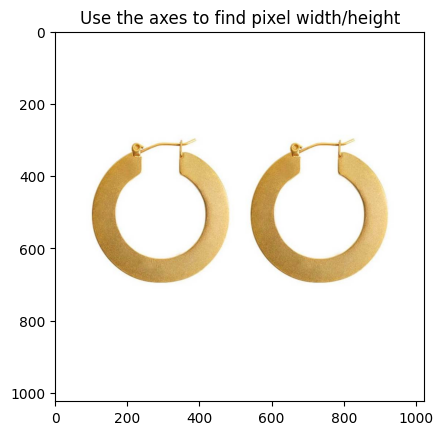

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread('earrings.jpg') 
plt.imshow(img)
plt.title("Use the axes to find pixel width/height")
plt.show()

### accroding tho the image grid choosed the height and width of a one ear ring as 400px

In [ ]:
import matplotlib.pyplot as plt

focal_length_mm = 8.0        
distance_to_object_mm = 720.0  
pixel_size_um = 2.2            # micrometers
pixel_size_mm = pixel_size_um / 1000.0  

# Ring measurements
pixel_width = 400   
pixel_height = 400  

# Calculate Image Size on the Sensor (in mm)
sensor_width_mm = pixel_width * pixel_size_mm
sensor_height_mm = pixel_height * pixel_size_mm

# Calculate Actual Real-World Size (in mm)
actual_width_mm = (sensor_width_mm * distance_to_object_mm) / focal_length_mm
actual_height_mm = (sensor_height_mm * distance_to_object_mm) / focal_length_mm

print(f"--- Results ---")
print(f"Measured Pixel Dimensions: {pixel_width}px x {pixel_height}px")
print(f"Actual Physical Size: {actual_width_mm:.2f} mm x {actual_height_mm:.2f} mm")
print(f"Actual Physical Size: {actual_width_mm/10:.2f} cm x {actual_height_mm/10:.2f} cm")

--- Results ---
Measured Pixel Dimensions: 400px x 400px
Actual Physical Size: 79.20 mm x 79.20 mm
Actual Physical Size: 7.92 cm x 7.92 cm


### **Camera Geometry Results**
Based on the **Pinhole Camera Model**, we calculated the physical dimensions of the earrings. 
- **Observation:** Given the large distance ($Z = 720$ mm) relative to the focal length ($f = 8$ mm), the magnification factor is quite small.
- **Accuracy:** The precision of these measurements depends on the accuracy of the manual pixel bounding-box selection.

In [ ]:
points = []

def click_event(event, x, y, flags, params):
    if event == cv2.EVENT_LBUTTONDOWN:
        print(f"Point captured: ({x}, {y})")
        cv2.circle(img, (x, y), 5, (0, 0, 255), -1)
        cv2.imshow('Capture Points', img)
        points.append([x, y])
        if len(points) == 4:
            print("Captured 4 points. Press any key to close and continue.")

img = cv2.imread('turf.jpg')

if img is None:
    print("Error: Could not load turf.jpg. Check the file path!")
else:
    cv2.imshow('Capture Points', img)
    
    cv2.setMouseCallback('Capture Points', click_event)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

    print("\nFinal Coordinates for dst_pts:")
    print(points)

Point captured: (684, 163)
Point captured: (839, 158)
Point captured: (1326, 660)
Point captured: (111, 664)
Captured 4 points. Press any key to close and continue.

Final Coordinates for dst_pts:
[[684, 163], [839, 158], [1326, 660], [111, 664]]


In [ ]:
turf = cv2.imread('turf.jpg')
flag = cv2.imread('srilanka.png') 
flag = cv2.rotate(flag, cv2.ROTATE_90_CLOCKWISE)
if turf is None or flag is None:
    print("Error: Could not find turf.jpg or flag.png. Check your filenames!")
else:
    h_f, w_f = flag.shape[:2]
    src_pts = np.array([
        [0, 0],           # Top-Left
        [w_f - 1, 0],     # Top-Right
        [w_f - 1, h_f - 1], # Bottom-Right
        [0, h_f - 1]      # Bottom-Left
    ], dtype=np.float32)

    dst_pts = np.array([
        [686, 163], # Top-Left
        [840, 160], # Top-Right
        [1329, 662],# Bottom-Right
        [95, 667]   # Bottom-Left
    ], dtype=np.float32)

    # Calculate the Homography Matrix (H)
    H, status = cv2.findHomography(src_pts, dst_pts)

    # Warp the flag to the turf's perspective
    warped_flag = cv2.warpPerspective(flag, H, (turf.shape[1], turf.shape[0]))

    # Create a Mask to blend the images
    mask = np.zeros_like(turf, dtype=np.uint8)
    cv2.fillConvexPoly(mask, dst_pts.astype(int), (255, 255, 255))

    # Final Overlay (Overlaying the warped flag onto the original turf)
    turf_no_pitch = cv2.bitwise_and(turf, cv2.bitwise_not(mask))
    final_result = cv2.add(turf_no_pitch, warped_flag)

    # Show and Save
    cv2.imshow('Final Flag Alignment', final_result)
    cv2.imwrite('alignment_result.jpg', final_result)
    print("Result saved")
    
    cv2.waitKey(0)
    cv2.destroyAllWindows()

Success! Result saved as alignment_result.jpg


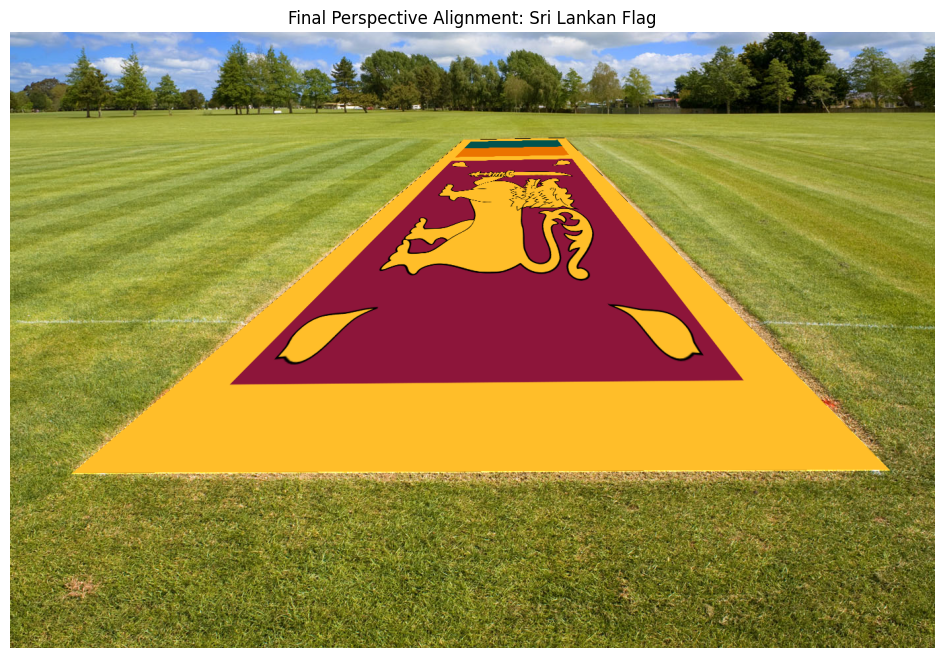

Success! Image displayed and saved as q3_alignment_result.jpg


In [ ]:
final_rgb = cv2.cvtColor(final_result, cv2.COLOR_BGR2RGB)
    
plt.figure(figsize=(12, 8))
plt.imshow(final_rgb)
plt.title("Final Perspective Alignment: Sri Lankan Flag")
plt.axis('off')
plt.show()

cv2.imwrite('q3_alignment_result.jpg', final_result)
print("Success! Image displayed and saved as q3_alignment_result.jpg")

## 3. Image Alignment via Planar Homography
### Projective Mapping
The superimposition is achieved through a planar homography $H \in PGL(2)$, representing the projective transformation between the flag plane and the ground plane. Since the scene involves a perspective view of a flat surface, the $3 \times 3$ matrix $H$ (with 8 Degrees of Freedom) is uniquely determined by 4 point correspondences.

### Implementation Details
* **Pre-processing:** The source image was rotated to align the principal axis of the flag with the longitudinal axis of the pitch to minimize anisotropic scaling.
* **Warping:** The forward mapping was implemented using a perspective warp, accounting for the convergence of parallel lines at the vanishing point.
* **Compositing:** A binary mask was generated from the destination vertices to perform a bitwise alpha-blend, ensuring a seamless insertion of the warped source into the target manifold.